In [1]:
import os
import re
import nltk
from nltk import Tree

import spacy
#spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm") 

import pandas as pd
import numpy as np

import textdescriptives as td

from dataset_evaluation.utils import add_column
from dataset_evaluation.evaluation_framework import EvaluationFramework

import folia.main as folia
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
from datasets import load_dataset

import pylangacq
import ast
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")

KeyboardInterrupt: 

# Datasets

## Generated corpus (tinystories)

In [ ]:
# generated corpus
tinystories = load_dataset('roneneldan/TinyStories', split='train[:1%]')
len(tinystories)

21197

In [ ]:
df_tinystories = pd.DataFrame(tinystories['text'], columns=['story'])
tiny_tinystories = df_tinystories[:1200].copy()

## Narrative dataset (Nipopolou)

In [ ]:
nico_path = '/Users/sabijn/Documents/PhD/Datasets/CHILDES_Nicolopoulou'
nicolopoulou = pylangacq.read_chat(nico_path)

df_narrative = pd.DataFrame({
    "text": [s.text() for s in nicolopoulou.stories()]
})

## Reference corpus (standard)

In [ ]:
CC_dataset = load_dataset('codymd/cc100_en_sample')
CC_dataset_text = CC_dataset['train']['text']

In [ ]:
ref_standard_dep = Path('datasets/CommonCrawl/CC_dep_lexicon_100000.csv')
ref_standard_uni = Path('datasets/CommonCrawl/CC_unigram_lexicon_100000.csv')
ref_standard_bi = Path('datasets/CommonCrawl/CC_bigram_lexicon_100000.csv')

## Reference corpus (spoken)

In [ ]:
ref_spoken_b_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/PeopleSpeech/PS_pos_bigram_100000.csv')
ref_spoken_u_csv  = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/PeopleSpeech/PS_pos_unigram_100000.csv')
ref_spoken_t_csv = Path('/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/PeopleSpeech/PS_pos_trigram_100000.csv')

# Evaluations

Linguistic annotations
- Syntactic tree depth per sentence according to the WNU_2022 paper (van Duijn & van Dijk, 2022)
    - Number of dependency arcs between root and leaf node.
- Average no. of complements per utterance
     - Counts (Open) clausal complements
- Sentence complexity (words before the root)
- Lexical diversity
    - Standard TTR (not implemented).  
    Dividing the number of unique tokens (types) by the total number of tokens.  
    Problem with TTR is that it is lower with a large amount of tokens
    - msTTR (mean segmental type-token ratio (TTR)): 
    
    - maTTR (moving average TTR)
    - MTLD (average number of words for which a consecutive TTR is maintained).  
    Measure of Textual Lexical Diversity.
    - MTLD (moving)
    - MTLD (bidirectional)
    - HDD (bidirectional)
- Vendi score
- Dependency constrained perplexity
- Regular perplexity
- Past tense use
- MAUVE (diversity)

In [ ]:
eval_f = EvaluationFramework(language='en',
                              pos_unigram=ref_spoken_u_csv, 
                              pos_bigram=ref_spoken_b_csv,
                              pos_trigram=ref_spoken_t_csv,
                              ref_unigram=ref_standard_uni,
                              ref_bigram=ref_standard_bi,
                              ref_ling_constrained=ref_standard_dep)

/Users/sabijn/Documents/PhD/code/storylm_p1_data/datasets/PeopleSpeech/PS_pos_unigram_100000.csv


No sentence-transformers model found with name bert-base-uncased. Creating a new one with mean pooling.


## Syntatic tree depth
-- van Duijn & van Dijk (2022)

In [ ]:
eval_f.add_pipe('syntactic_depth')

## Average no. of complements per utterance

In [ ]:
eval_f.add_pipe('average_components')

## Sentence complexity
-- ChiSCor (2023) - Average number of words before the root

In [ ]:
eval_f.add_pipe('wbr_average')

## Lexical diversity
-- ChiSCor (2023)

In [ ]:
eval_f.add_pipe('lexical_diversity')

## Dependency distance
-- ChiSCor (2023)

In [ ]:
eval_f.add_pipe('dependency_distance')

## Local contextuality

In [ ]:
eval_f.add_pipe("local_contextuality")

## Grammaticality

$G(story) = \dfrac{\sum^k_{i=1}(G(s_i))}{k}$, with $s$ a sentence in the story.  
  
$G(sentence) = P(seq) = \log(\sqrt[n]{\prod_{i=1}^n \left( P(K_i) \right)})$.  
  
$P(K_i) = P(t_3t_2t_1) = \lambda_1 \cdot P(t_3|t_1t_2) + \lambda_2 \cdot P(t_3|t_2) + \lambda_3 \cdot P(t_3)$, where  
  
- where $\lambda_1 + \lambda_2 + \lambda_3 = 1$, ($\lambda_1 = 0.5, \lambda_2 = 0.3, \lambda_3 = 0.2 \rightarrow$ vadlapudi (2010))
- $P(t_3|t_1t_2) = \dfrac{f(t_1t_2t_3)}{f(t_1t_2)}$.  
- $P(t_3|t_2) = \dfrac{f(t_2t_3)}{f(t_2)}$.  
- $P(t_3) = \dfrac{f(t_3)}{\sum_{\forall t_i} f(t_i)}$


In [ ]:
eval_f.add_pipe('grammaticality')

## Creative perplexity

In [ ]:
eval_f.add_pipe('creative_perplexity_unigram')
eval_f.add_pipe('creative_perplexity_bigram')
eval_f.add_pipe('creative_perplexity_bigram_constrained')

## Vendi score
-- [Friedman (2023) The Vendi Score: A Diversity Evaluation Metric for Machine Learning](https://github.com/vertaix/Vendi-Score)

In [ ]:
eval_f.add_pipe("vendi_ngram")
eval_f.add_pipe("vendi_embeddings")

## Run pipeline (real data)

In [ ]:
def load_or_run_eval(eval_f, dataset, column, path_name, *, run=False):
    if Path(path_name).exists() and not run:
        df = pd.read_csv(path_name)
        if 'lexical_diversity' in df.columns:
            df['lexical_diversity'] = df['lexical_diversity'].apply(ast.literal_eval)
            
        return df

    dataset = eval_f.run_pipeline_on_df(dataset, column)
    dataset.to_csv(path_name, index=False)
    return dataset

In [ ]:
df_narrative = load_or_run_eval(eval_f, df_narrative, 'text', 'results/nicolopoulou_eval_results.csv')

In [ ]:
df_narrative['msTTR'] = df_narrative.apply(lambda row: eval_f.run_component('lexical_diversity', row['text'], methods="msTTR"), axis = 1) 

## Run pipeline (tinystories)

In [ ]:
tiny_tinystories = load_or_run_eval(eval_f, tiny_tinystories, 'story', 'results/tinytinystories_eval_results.csv')

In [ ]:
tiny_tinystories['msTTR'] = tiny_tinystories.apply(lambda row: eval_f.run_component('lexical_diversity', row['story'], methods="msTTR"), axis = 1) 

## MAUVE
-- Pillutla (2021), see also Peeperkorn (NYP)

**Good to know**
- Mauve can have low scores due to lack of variety or poor quality.
- Adjust size of the histogram (num_buckets) based on the amount of trainingssamples (rule of thumb ``num_buckets < floor( #pred + #ref ) / 39)``).  
- Automatically runs gpt2
- Runs only with numpy 1.x not with numpy 2.x
- MAUVE score, which ranges between 0 and 1. Larger values indicate that P and Q are closer.
- Frontier Integral, which ranges between 0 and 1. Smaller values indicate that P and Q are closer.

**Usefull links**     
https://github.com/krishnap25/mauve.  
https://pypi.org/project/mauve-text/.  
https://huggingface-co.translate.goog/spaces/evaluate-metric/mauve?_x_tr_sl=en&_x_tr_tl=nl&_x_tr_hl=nl&_x_tr_pto=sc. 

In [ ]:
# from evaluate import load

# mauve = load('mauve')
# p_text = CC_dataset_text[:1200]
# q_text = tiny_tinystories['story'].to_list()

# out = mauve.compute(
#     predictions=p_text,
#     references=q_text,
#     num_buckets=30,          
#     featurize_model_name="gpt2",   
#     device_id=-1,                  # force CPU featurization
#     max_text_length=256,           # default is 1024
#     kmeans_num_redo=1,             
#     kmeans_max_iter=100,           
#     pca_max_data=5000,            # cap PCA sample (use -1 to use all)
#     verbose=True
# )

# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

In [ ]:
# q_text = df_narrative['text'].to_list()

# out = mauve.compute(predictions=p_text, references=q_text, num_buckets=50)
# plt.plot(out.divergence_curve[:, 1], out.divergence_curve[:, 0])

## Vendi score overall

In [ ]:
from vendi_score import text_utils

ngram_vs_nico = text_utils.ngram_vendi_score(list(map(str, df_narrative['text'].to_list())), ns=[1, 2, 3, 4])
ngram_vs_tiny = text_utils.ngram_vendi_score(list(map(str, tiny_tinystories['story'].to_list())), ns=[1, 2, 3, 4])
print('Vendi score Nicolopoulou:', ngram_vs_nico)
print('Vendi score TinyStories:', ngram_vs_tiny)

/opt/miniconda3/envs/storylmdata/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vendi score Nicolopoulou: 212.83598433548977
Vendi score TinyStories: 425.5606300496613


## Plotting and analysis

In [ ]:
def plot_histogram(data, binsize=30, figure_size=(8,6), title='Dependency-constraint perplexities', xlabel='Perplexity', ylabel='Frequency'):
    plt.figure(figsize=figure_size)
    plt.hist(data, bins=binsize, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.75)

In [ ]:
def plot_overlapping_hist(data1,
                          data2, 
                          *,
                          binsize=30, 
                          figure_size=(8,6), 
                          title='Dependency-constraint perplexities', 
                          xlabel='Perplexity', 
                          ylabel='Frequency',
                          label1='TinyStories',
                          label2='TinyStories'):
    plt.figure(figsize=figure_size)
    plt.hist(data1, bins=binsize, color='steelblue', alpha=0.6, label=label1)
    plt.hist(data2, bins=binsize, color='darkorange', alpha=0.6, label=label2)

    # Add labels and legend
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()

In [ ]:
def plot_violin_plot(data1, data2, *, xlabels=None, ylabel=None, title=None, outliers=False, showmeans=True, showmedians=True, showextrema=True):
    _, ax = plt.subplots()

    data = [data1, data2]
    axes = ax.violinplot(data, showmeans=showmeans, showmedians=showmedians, showextrema=showextrema)

    axes['cmeans'].set_linestyle("-")
    axes['cmedians'].set_linestyle("--")

    # Custom legend handles
    legend_elements = [
        Line2D([0], [0], color="steelblue", lw=1, linestyle="-", label="Mean"),
        Line2D([0], [0], color="steelblue", lw=1, linestyle="--", label="Median")
    ]

    # Overlay a boxplot with fliers (outliers)
    if outliers:
        ax.boxplot(data, positions=[1, 2], widths=0.1,
                showfliers=True,
                showcaps=False,
                boxprops={'color':'none'},
                whiskerprops={'linewidth':0},
                medianprops={'linewidth':0},
                flierprops=dict(marker='D', markerfacecolor='steelblue', markersize=4,
                        linestyle='none', markeredgecolor='steelblue'))
        legend_elements.append(Line2D([0], [0], marker='D', color='w', label="Outliers",
           markerfacecolor='steelblue', markeredgecolor='steelblue', markersize=4))

    ax.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(xlabels)
    ax.set_ylabel(ylabel)
    plt.title(title)

In [ ]:
df_narrative.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'text', 'syntactic_depth',
       'average_components', 'wbr_average', 'lexical_diversity',
       'dependency_distance', 'local_contextuality', 'grammaticality',
       'creative_perplexity_unigram', 'creative_perplexity_bigram',
       'creative_perplexity_bigram_constrained', 'vendi_ngram',
       'vendi_embeddings', 'msTTR'],
      dtype='object')

In [ ]:
df_narrative['dependency_distance'] = df_narrative.apply(lambda row: eval_f.run_component('dependency_distance', row['text']), axis=1)
tiny_tinystories['dependency_distance'] = tiny_tinystories.apply(lambda row: eval_f.run_component('dependency_distance', row['story']), axis=1)

df_narrative.to_csv('results/nicolopoulou_eval_results.csv', index=False)
tiny_tinystories.to_csv('results/tinytinystories_eval_results.csv', index=False)


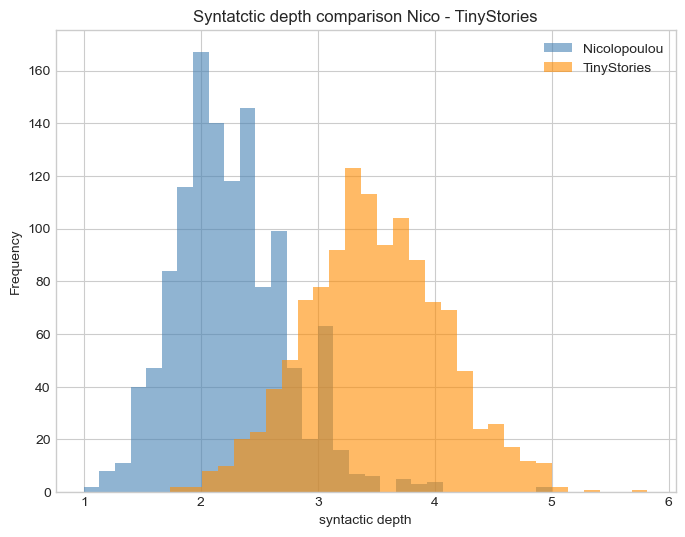

In [ ]:
plot_overlapping_hist(df_narrative['syntactic_depth'], 
                      tiny_tinystories['syntactic_depth'],
                      title='Syntatctic depth comparison Nico - TinyStories',
                      xlabel='syntactic depth',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )


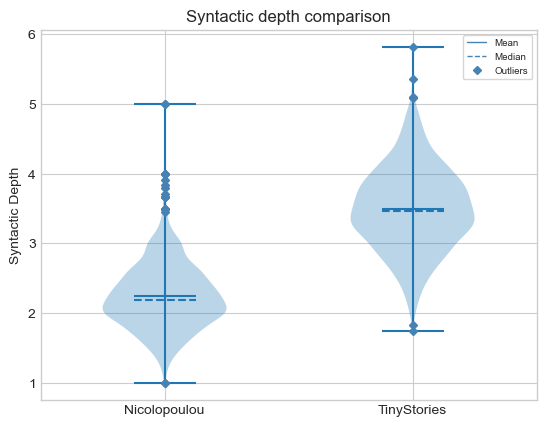

In [ ]:
plot_violin_plot(df_narrative['syntactic_depth'], 
                 tiny_tinystories['syntactic_depth'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Syntactic Depth',
                 title="Syntactic depth comparison", 
                 outliers=True)

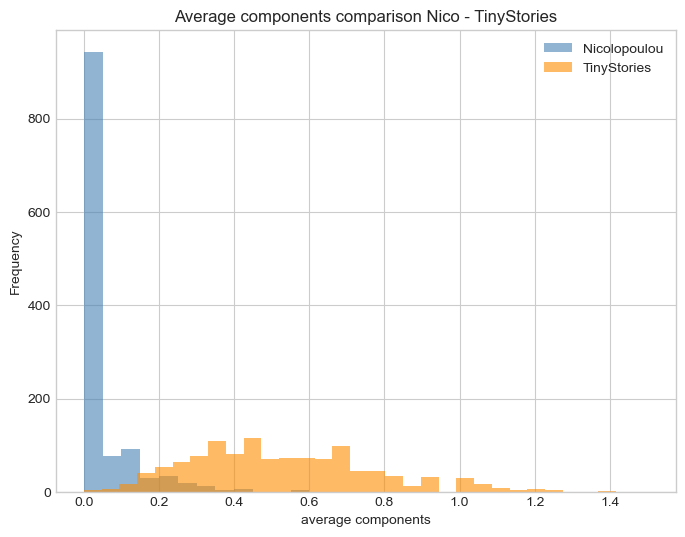

In [ ]:
plot_overlapping_hist(df_narrative['average_components'], 
                      tiny_tinystories['average_components'],
                      title='Average components comparison Nico - TinyStories',
                      xlabel='average components',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )


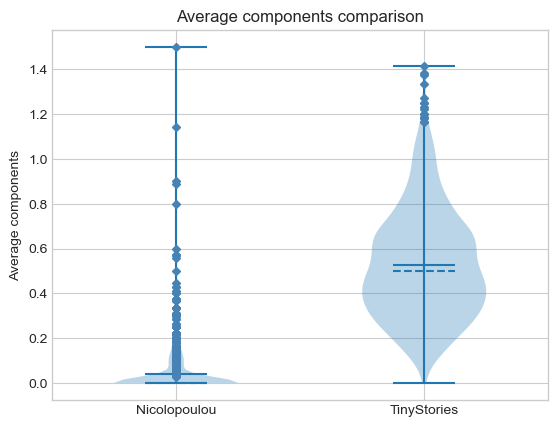

In [ ]:
plot_violin_plot(df_narrative['average_components'], 
                 tiny_tinystories['average_components'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Average components',
                 title="Average components comparison", 
                 outliers=True)

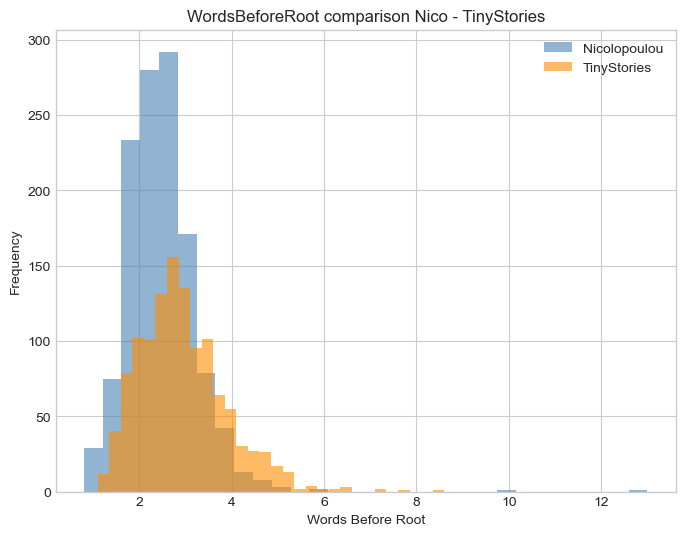

In [ ]:
plot_overlapping_hist(df_narrative['wbr_average'], 
                      tiny_tinystories['wbr_average'],
                      title='WordsBeforeRoot comparison Nico - TinyStories',
                      xlabel='Words Before Root',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

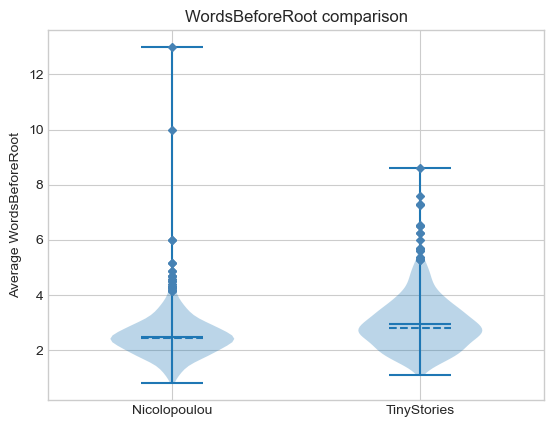

In [ ]:
plot_violin_plot(df_narrative['wbr_average'], 
                 tiny_tinystories['wbr_average'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Average WordsBeforeRoot',
                 title="WordsBeforeRoot comparison", 
                 outliers=True)

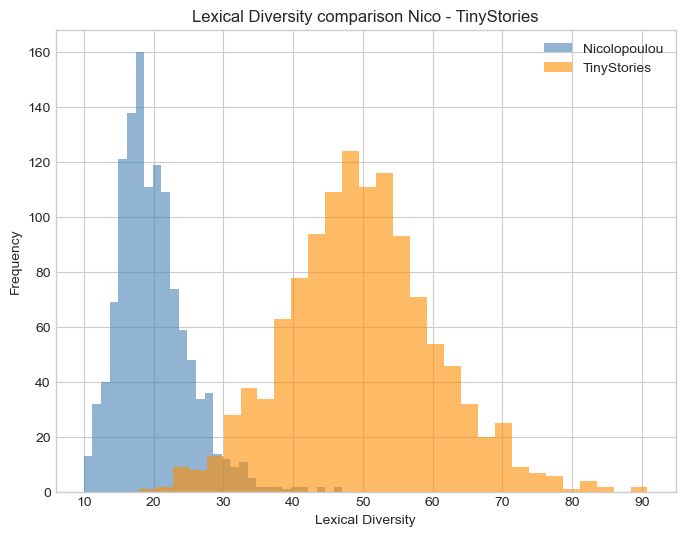

In [ ]:
plot_overlapping_hist(df_narrative['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                      tiny_tinystories['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(),
                      title='Lexical Diversity comparison Nico - TinyStories',
                      xlabel='Lexical Diversity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

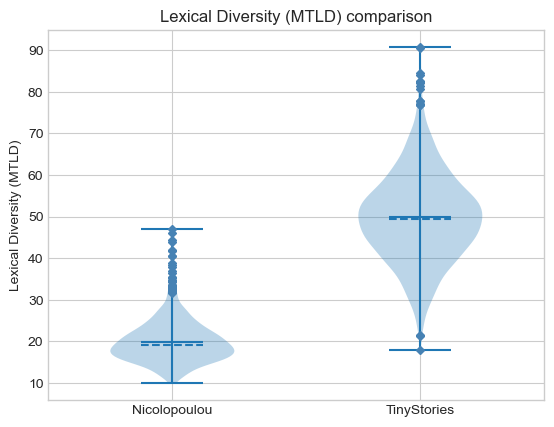

In [ ]:
plot_violin_plot(df_narrative['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 tiny_tinystories['lexical_diversity'].apply(lambda x: x.get("moving_mtld")).tolist(), 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Lexical Diversity (MTLD)',
                 title="Lexical Diversity (MTLD) comparison", 
                 outliers=True)

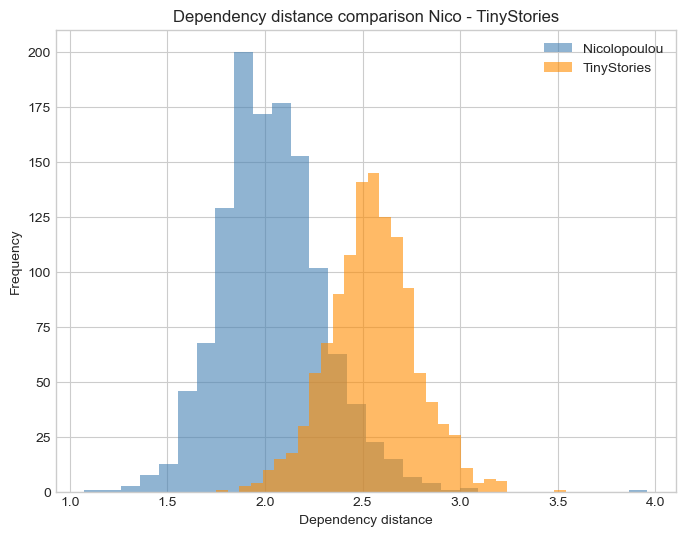

In [ ]:
plot_overlapping_hist(df_narrative['dependency_distance'], 
                      tiny_tinystories['dependency_distance'],
                      title='Dependency distance comparison Nico - TinyStories',
                      xlabel='Dependency distance',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

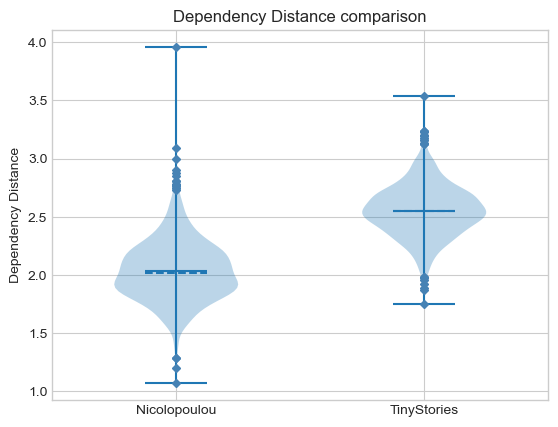

In [ ]:
plot_violin_plot(df_narrative['dependency_distance'], 
                 tiny_tinystories['dependency_distance'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Dependency Distance',
                 title="Dependency Distance comparison", 
                 outliers=True)

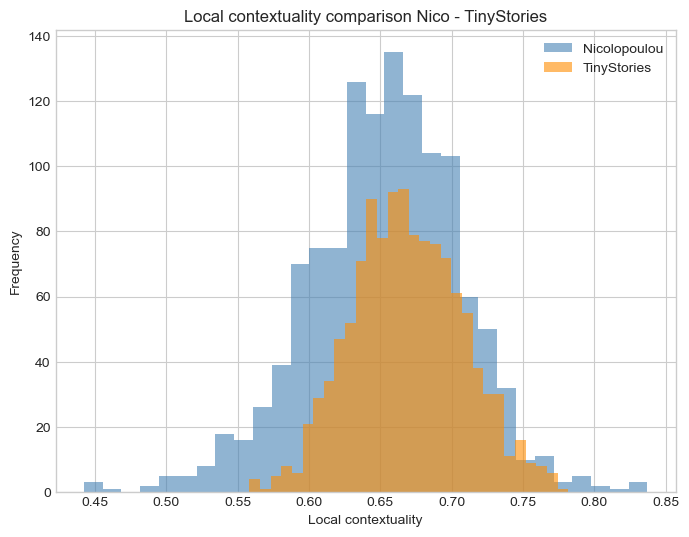

In [ ]:
plot_overlapping_hist(df_narrative['local_contextuality'][df_narrative['local_contextuality'] > 0.01].tolist(), # took out the 0.0 (no sentences)
                      tiny_tinystories['local_contextuality'],
                      title='Local contextuality comparison Nico - TinyStories',
                      xlabel='Local contextuality',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped 3 stories ([249, 250, 253]). 


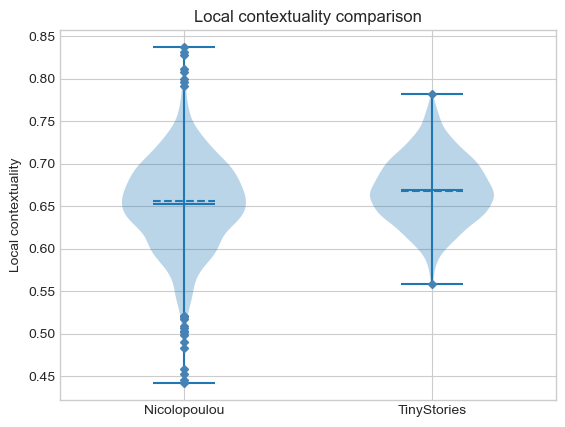

In [ ]:
zero_values = df_narrative['local_contextuality'].isin([0.0])

print(f"""Info: 0.0 values are skipped. These are instances with only 1 sentence.
      Skipped {zero_values.sum(axis=0)} stories ({df_narrative.index[zero_values].tolist()}). """)
plot_violin_plot(df_narrative['local_contextuality'][df_narrative['local_contextuality'] != 0.0], 
                 tiny_tinystories['local_contextuality'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Local contextuality',
                 title="Local contextuality comparison", 
                 outliers=True)

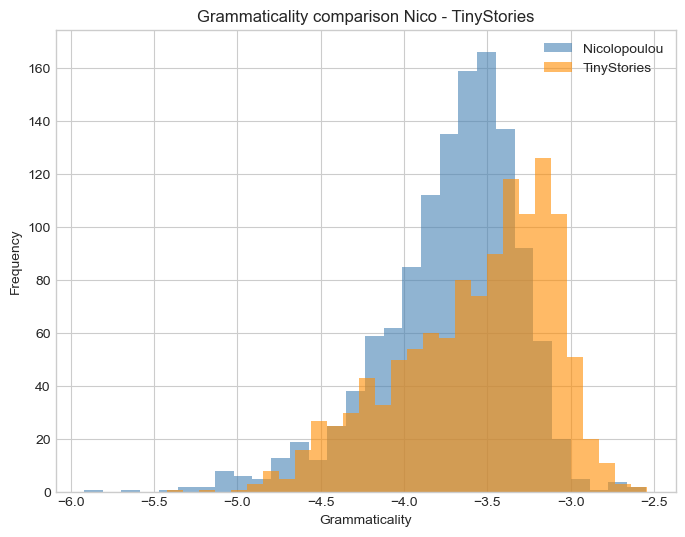

In [ ]:
plot_overlapping_hist(df_narrative['grammaticality'], 
                      tiny_tinystories['grammaticality'],
                      title='Grammaticality comparison Nico - TinyStories',
                      xlabel='Grammaticality',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

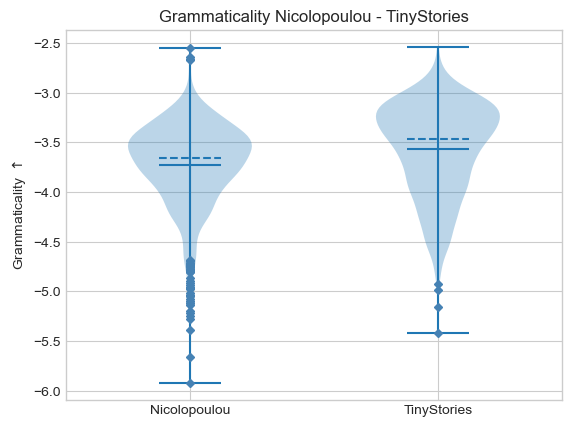

In [ ]:
plot_violin_plot(df_narrative['grammaticality'], 
                 tiny_tinystories['grammaticality'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel=r'Grammaticality $\uparrow$',
                 title="Grammaticality Nicolopoulou - TinyStories", 
                 outliers=True)

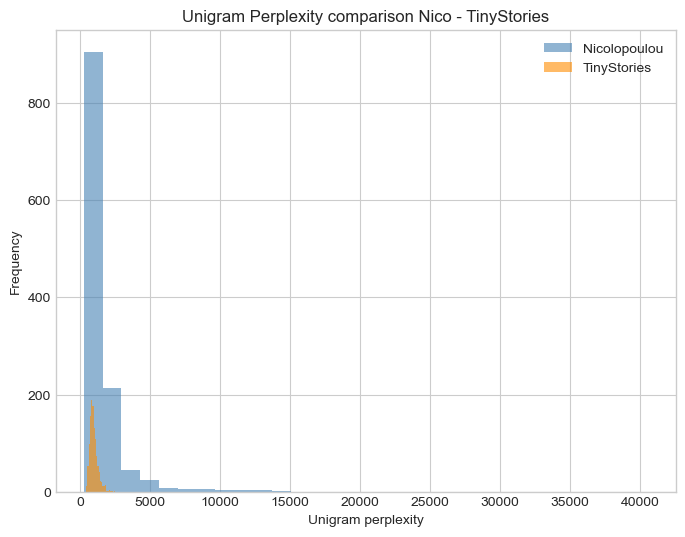

In [ ]:
plot_overlapping_hist(df_narrative['creative_perplexity_unigram'], 
                      tiny_tinystories['creative_perplexity_unigram'],
                      title='Unigram Perplexity comparison Nico - TinyStories',
                      xlabel='Unigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

In [ ]:
df_narrative['text'].iloc[1041]

'once upon a time Thomas Choo Choo Train and Henry Choo Choo Train and Asher Choo Choo Train pretend crashed. the end.'

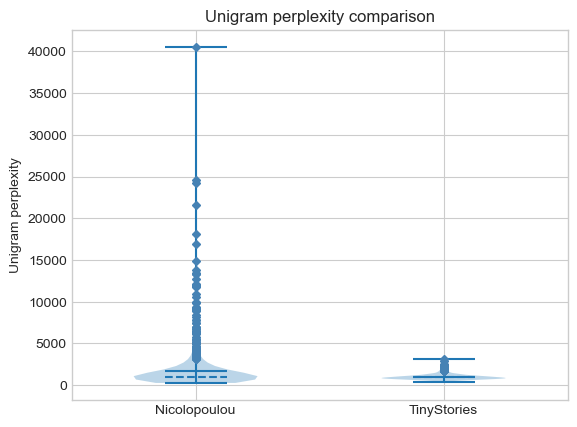

In [ ]:
plot_violin_plot(df_narrative['creative_perplexity_unigram'], 
                 tiny_tinystories['creative_perplexity_unigram'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Unigram perplexity',
                 title="Unigram perplexity comparison", 
                 outliers=True)

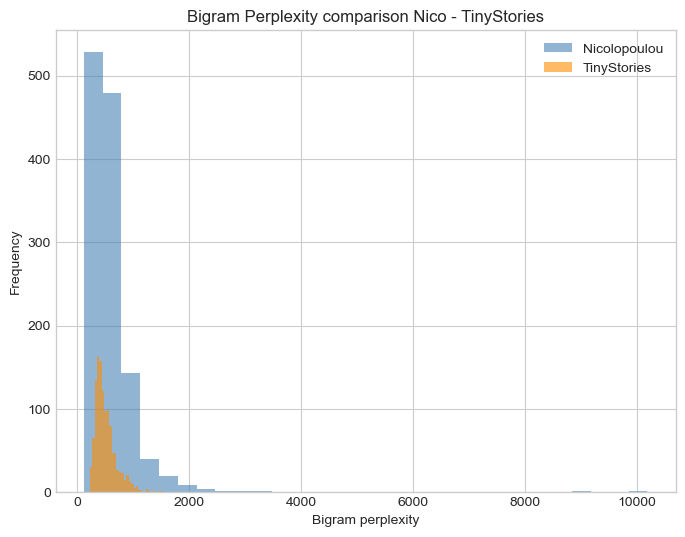

In [ ]:
plot_overlapping_hist(df_narrative['creative_perplexity_bigram'], 
                      tiny_tinystories['creative_perplexity_bigram'],
                      title='Bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

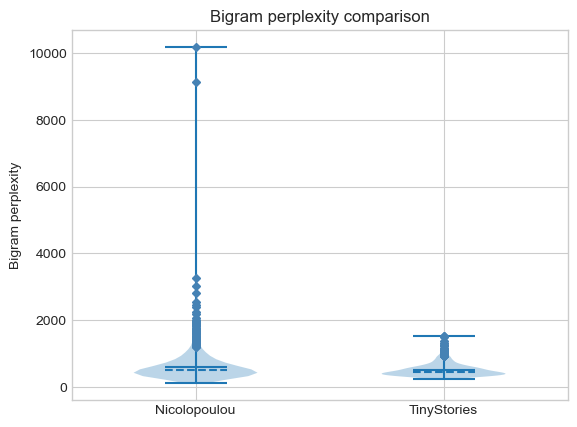

In [ ]:
plot_violin_plot(df_narrative['creative_perplexity_bigram'], 
                 tiny_tinystories['creative_perplexity_bigram'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Bigram perplexity',
                 title="Bigram perplexity comparison", 
                 outliers=True)

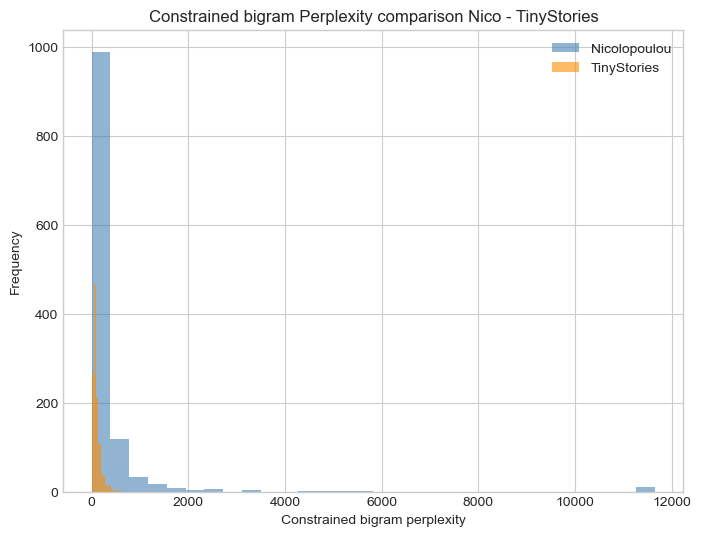

In [ ]:
plot_overlapping_hist(df_narrative['creative_perplexity_bigram_constrained'], 
                      tiny_tinystories['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

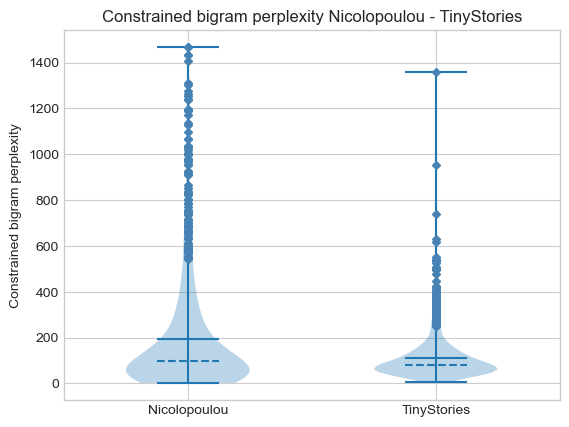

In [ ]:
plot_violin_plot(df_narrative['creative_perplexity_bigram_constrained'][df_narrative['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                 tiny_tinystories['creative_perplexity_bigram_constrained'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Constrained bigram perplexity',
                 title='Constrained bigram perplexity Nicolopoulou - TinyStories', 
                 outliers=True)

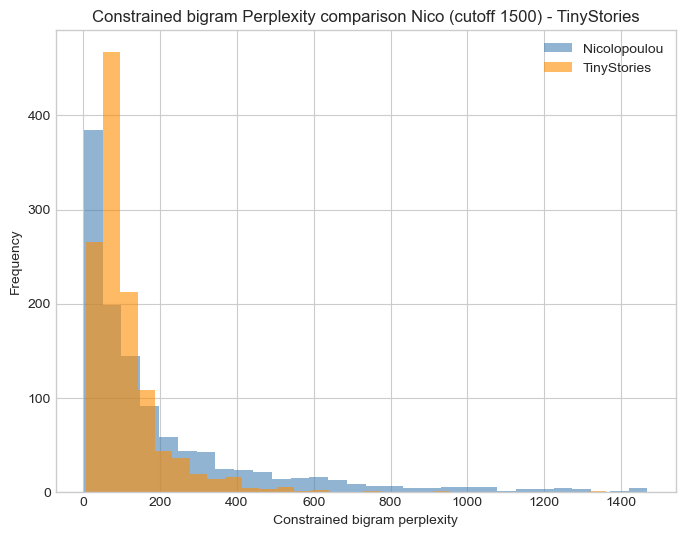

In [ ]:
plot_overlapping_hist(df_narrative['creative_perplexity_bigram_constrained'][df_narrative['creative_perplexity_bigram_constrained'] < 1500].tolist(), 
                      tiny_tinystories['creative_perplexity_bigram_constrained'],
                      title='Constrained bigram Perplexity comparison Nico (cutoff 1500) - TinyStories',
                      xlabel='Constrained bigram perplexity',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

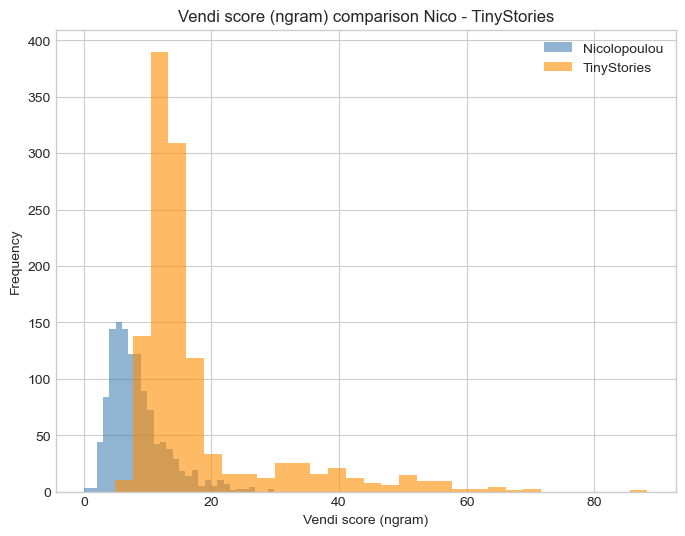

In [ ]:
plot_overlapping_hist(df_narrative['vendi_ngram'], 
                      tiny_tinystories['vendi_ngram'],
                      title='Vendi score (ngram) comparison Nico - TinyStories',
                      xlabel='Vendi score (ngram)',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

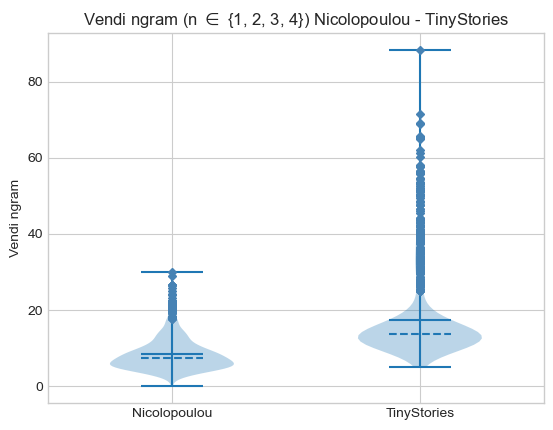

In [ ]:
plot_violin_plot(df_narrative['vendi_ngram'], 
                 tiny_tinystories['vendi_ngram'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Vendi ngram',
                 title=r'Vendi ngram (n $\in$ {1, 2, 3, 4}) Nicolopoulou - TinyStories', 
                 outliers=True)

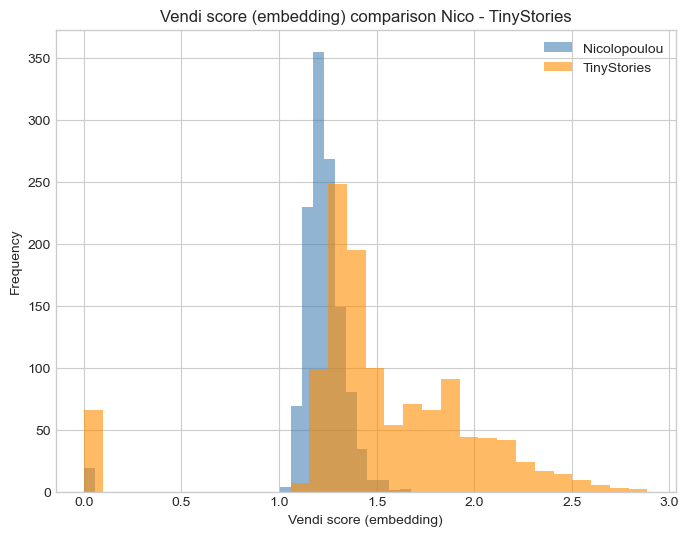

In [ ]:
plot_overlapping_hist(df_narrative['vendi_embeddings'], 
                      tiny_tinystories['vendi_embeddings'],
                      title='Vendi score (embedding) comparison Nico - TinyStories',
                      xlabel='Vendi score (embedding)',
                      label1='Nicolopoulou',
                      label2='TinyStories'
                      )

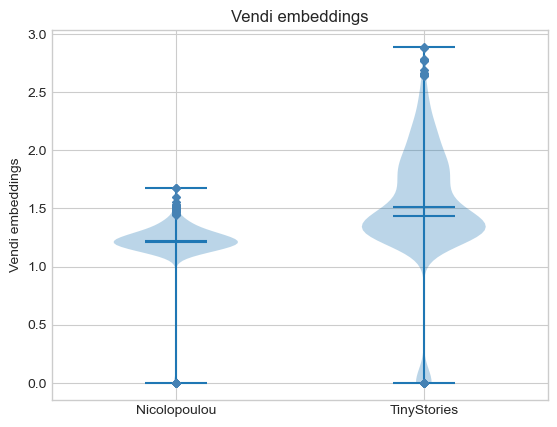

In [ ]:
plot_violin_plot(df_narrative['vendi_embeddings'], 
                 tiny_tinystories['vendi_embeddings'], 
                 xlabels=['Nicolopoulou', 'TinyStories'], 
                 ylabel='Vendi embeddings',
                 title='Vendi embeddings', 
                 outliers=True)